WHY DO YOU EVEN KNOW AUTOGRAD?

LETS SAY Y=X^2
progra,(X)-> dy/dx

dy/dx=2x

but what if

y=x^2

z=sin(y)

dz/dx= dz/dy * dy/dx


but what if

y=x^2

z=sin(y)

u=coz(z)

du/dx=du/dz*dz/dy*dy/dx

as u make the nested functions complex and complex coding them and finding the derivative becomes more difficult


Autograd is the core component of pytorch that provide automatic derivatives for the tensors there are for training the network

# Autograd

In [1]:
import torch
import math

In [2]:
x= torch.tensor(3.0,requires_grad=True)


In [19]:
x

tensor(3., requires_grad=True)

In [20]:
y=x**2

In [21]:
y

tensor(9., grad_fn=<PowBackward0>)

In [23]:
z=torch.sin(y)

In [24]:
z

tensor(0.4121, grad_fn=<SinBackward0>)

In [25]:
z.backward()

In [26]:
x.grad

tensor(-5.4668)

In [4]:
import torch

# 1. Setup Hyperparameters & Data
input_dim = 2
hidden_dim = 4
output_dim = 1
learning_rate = 0.3
epochs = 500

# Generate synthetic XOR data using pure PyTorch
# 4 points: [0,0], [0,1], [1,0], [1,1]
X = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]], dtype=torch.float32)
y = torch.tensor([[0.0], [1.0], [1.0], [0.0]], dtype=torch.float32)

# 2. Initialize Weights and Biases (Crucial: requires_grad=True)
W1 = torch.randn(input_dim, hidden_dim, requires_grad=True)
b1 = torch.zeros(1, hidden_dim, requires_grad=True)
W2 = torch.randn(hidden_dim, output_dim, requires_grad=True)
b2 = torch.zeros(1, output_dim, requires_grad=True)

# 3. Training Loop
for epoch in range(epochs):
    # --- Forward Pass ---
    # TODO: Compute hidden layer outputs (Linear transformation + Tanh activation)
    # Hint: use torch.matmul() or the @ operator, and torch.tanh()
    z1 = torch.matmul(X, W1) + b1
    a1 = torch.tanh(z1)


    # TODO: Compute output layer (Linear transformation + Sigmoid activation)
    # Hint: use torch.sigmoid()
    z2 = torch.matmul(a1, W2) + b2
    y_pred = torch.sigmoid(z2)

    # --- Compute Loss ---
    # TODO: Calculate Binary Cross Entropy (BCE) Loss manually
    # Formula: -mean(y * log(y_pred) + (1 - y) * log(1 - y_pred))
    loss=-torch.mean(y*torch.log(y_pred) + (1-y)*torch.log(1-y_pred))

    # --- Backward Pass ---
    # TODO: Trigger autograd to calculate the gradients
    loss.backward()
    # --- Update Weights (Gradient Descent) ---
    with torch.no_grad():
        # TODO: Update W1, b1, W2, b2 using their .grad attributes and learning_rate
        W1 -= learning_rate * W1.grad
        W2 -= learning_rate * W2.grad
        b1 -= learning_rate * b1.grad
        b2 -= learning_rate * b2.grad

         # TODO: Zero out the gradients so they don't accumulate in the next epoch

        W1.grad.zero_()
        b1.grad.zero_()
        W2.grad.zero_()
        b2.grad.zero_()



    # Print progress
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# 4. Evaluation
print("\n--- Final Predictions ---")
with torch.no_grad():
    # Re-run forward pass one last time to get final y_pred
    z1 = torch.tanh(torch.matmul(X, W1) + b1)
    final_pred = torch.sigmoid(torch.matmul(z1, W2) + b2)

    for i in range(len(X)):
        binary_pred = 1.0 if final_pred[i] > 0.5 else 0.0
        print(f"Input: {X[i].tolist()} -> Predicted Prob: {final_pred[i].item():.4f} (Class: {binary_pred}) | Target: {y[i].item()}")

Epoch [100/500], Loss: 0.5026
Epoch [200/500], Loss: 0.1531
Epoch [300/500], Loss: 0.0578
Epoch [400/500], Loss: 0.0337
Epoch [500/500], Loss: 0.0235

--- Final Predictions ---
Input: [0.0, 0.0] -> Predicted Prob: 0.0100 (Class: 0.0) | Target: 0.0
Input: [0.0, 1.0] -> Predicted Prob: 0.9735 (Class: 1.0) | Target: 1.0
Input: [1.0, 0.0] -> Predicted Prob: 0.9722 (Class: 1.0) | Target: 1.0
Input: [1.0, 1.0] -> Predicted Prob: 0.0280 (Class: 0.0) | Target: 0.0


In [3]:
import sklearn
print(sklearn.__version__)

1.9.0


In [5]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_computational_graph():
    G = nx.DiGraph()

    # Define Nodes (Inputs, Parameters, Operations, Outputs)
    nodes = {
        "X": "Input (X)",
        "W1": "Weight (W1)",
        "b1": "Bias (b1)",
        "Z1": "Linear (X@W1 + b1)",
        "A1": "Activation (Tanh)",
        "W2": "Weight (W2)",
        "b2": "Bias (b2)",
        "Z2": "Linear (A1@W2 + b2)",
        "Y_pred": "Prediction (Sigmoid)",
        "Y": "Target (Y)",
        "Loss": "BCE Loss"
    }

    for node, label in nodes.items():
        G.add_node(node, label=label)

    # Connect edges indicating forward flow (gradients flow backwards along these)
    edges = [
        ("X", "Z1"), ("W1", "Z1"), ("b1", "Z1"),
        ("Z1", "A1"),
        ("A1", "Z2"), ("W2", "Z2"), ("b2", "Z2"),
        ("Z2", "Y_pred"),
        ("Y_pred", "Loss"), ("Y", "Loss")
    ]
    G.add_edges_from(edges)

    pos = {
        "X": (0, 2), "W1": (0, 1), "b1": (0, 0),
        "Z1": (1, 1), "A1": (2, 1),
        "W2": (2, -1), "b2": (2, -2),
        "Z2": (3, 0), "Y_pred": (4, 0), "Y": (4, -1.5),
        "Loss": (5, -0.5)
    }

    plt.figure(figsize=(10, 6))
    labels = nx.get_node_attributes(G, 'label')
    nx.draw(G, pos, with_labels=True, labels=labels, node_color='skyblue',
            node_size=2500, font_size=8, font_weight='bold', arrowsize=15)
    plt.title("Neural Network Computational Graph (Forward Flow -> / Backward Gradients <-)")
    plt.savefig("computational_graph.png")
    plt.close()
    print("Saved 'computational_graph.png'")

def draw_gradient_accumulation():
    G = nx.DiGraph()

    # Step-by-step nodes showing how values aggregate
    G.add_node("Epoch1", label="Epoch 1 Grad\n(+2.0)")
    G.add_node("Epoch2", label="Epoch 2 Grad\n(+1.8)")
    G.add_node("Accum", label="W1.grad Buffer\n(Sum: 3.8)")
    G.add_node("Update", label="Weight Update\nW1 -= LR * 3.8\n(CORRUPTED)")

    G.add_edge("Epoch1", "Accum")
    G.add_edge("Epoch2", "Accum")
    G.add_edge("Accum", "Update")

    pos = {"Epoch1": (0, 1), "Epoch2": (0, -1), "Accum": (1, 0), "Update": (2, 0)}
    labels = nx.get_node_attributes(G, 'label')

    plt.figure(figsize=(8, 4))
    nx.draw(G, pos, with_labels=True, labels=labels, node_color='salmon',
            node_size=3500, font_size=9, font_weight='bold', arrowsize=15)
    plt.title("What Happens When You Forget .zero_()")
    plt.savefig("gradient_accumulation.png")
    plt.close()
    print("Saved 'gradient_accumulation.png'")

if __name__ == "__main__":
    draw_computational_graph()
    draw_gradient_accumulation()

Saved 'computational_graph.png'
Saved 'gradient_accumulation.png'


--- Computational Graph ---


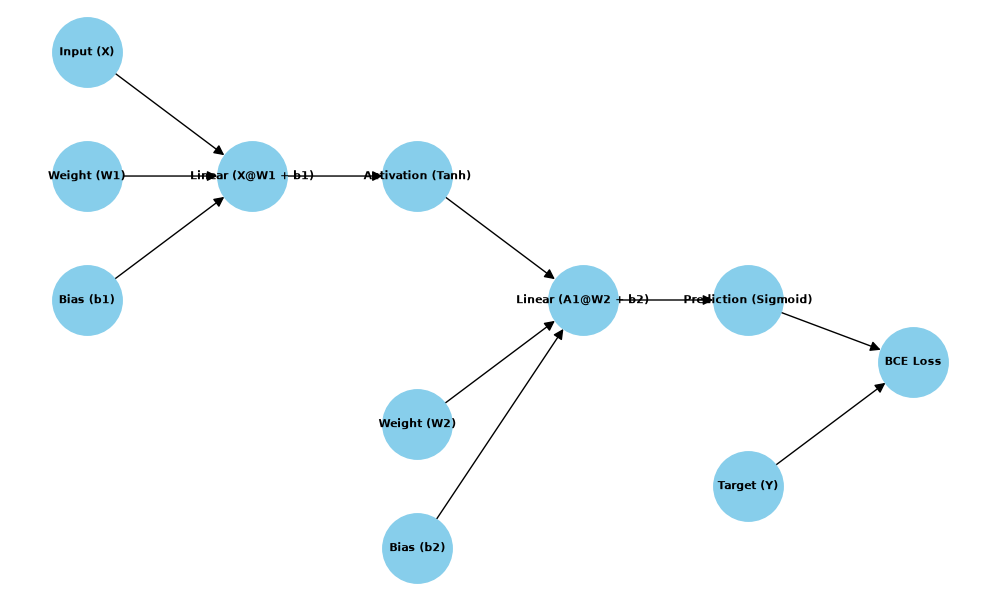


--- Gradient Accumulation Problem ---


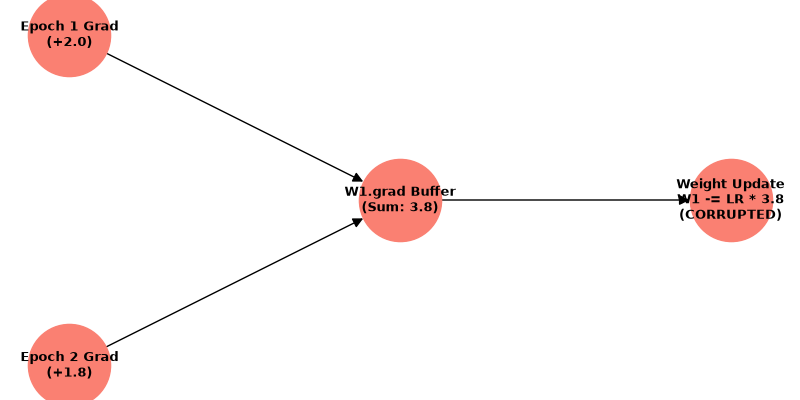

In [6]:
from IPython.display import Image, display

print("--- Computational Graph ---")
display(Image(filename='computational_graph.png'))

print("\n--- Gradient Accumulation Problem ---")
display(Image(filename='gradient_accumulation.png'))

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_pytorch_dynamic_graph():
    G = nx.DiGraph()

    # Nodes defining the lifecycle
    nodes = {
        "Py1": "Python Loop\n(Epoch 1)",
        "Exec1": "Eager Execution\n(Math happens instantly)",
        "Tape1": "Autograd Tape\n(Records Graph)",
        "Back1": ".backward()\n(Calculates & Destroys Graph)",
        "Py2": "Python Loop\n(Epoch 2)",
        "Exec2": "Eager Execution\n(Math happens instantly)",
        "Tape2": "Autograd Tape\n(Builds NEW Graph)",
        "Back2": ".backward()\n(Calculates & Destroys Graph)"
    }

    for node, label in nodes.items():
        G.add_node(node, label=label)

    edges = [
        ("Py1", "Exec1"), ("Exec1", "Tape1"), ("Tape1", "Back1"),
        ("Back1", "Py2"), ("Py2", "Exec2"), ("Exec2", "Tape2"), ("Tape2", "Back2")
    ]
    G.add_edges_from(edges)

    pos = {
        "Py1": (0, 1), "Exec1": (1, 1), "Tape1": (2, 1), "Back1": (3, 1),
        "Py2": (0, 0), "Exec2": (1, 0), "Tape2": (2, 0), "Back2": (3, 0)
    }

    plt.figure(figsize=(12, 5))
    labels = nx.get_node_attributes(G, 'label')
    # PyTorch classic orange/red theme
    nx.draw(G, pos, with_labels=True, labels=labels, node_color='#ffcccc',
            node_size=3500, font_size=8, font_weight='bold', arrowsize=20, edge_color='gray')
    plt.title("PyTorch: Dynamic Eager Execution (Define-by-Run)")
    plt.savefig("pytorch_dynamic_graph.png", bbox_inches='tight')
    plt.close()
    print("Saved 'pytorch_dynamic_graph.png'")

def draw_jax_static_graph():
    G = nx.DiGraph()

    # Nodes defining the lifecycle
    nodes = {
        "PyFunc": "Pure Python Function\n(f(x, w))",
        "Tracer": "JAX Tracer\n(Passes dummy shapes)",
        "JAXpr": "Static JAXpr Graph\n(Intermediate Rep.)",
        "XLA": "XLA Compiler\n(Fuses GPU Kernels)",
        "Binary": "Optimized Machine Code\n(Zero Python Overhead)",
        "Exec1": "Hardware Execution\n(Epoch 1)",
        "Exec2": "Hardware Execution\n(Epoch 2)",
        "Exec3": "Hardware Execution\n(Epoch 3)"
    }

    for node, label in nodes.items():
        G.add_node(node, label=label)

    edges = [
        ("PyFunc", "Tracer"), ("Tracer", "JAXpr"), ("JAXpr", "XLA"), ("XLA", "Binary"),
        ("Binary", "Exec1"), ("Binary", "Exec2"), ("Binary", "Exec3")
    ]
    G.add_edges_from(edges)

    pos = {
        "PyFunc": (0, 0), "Tracer": (1, 0), "JAXpr": (2, 0),
        "XLA": (3, 0), "Binary": (4, 0),
        "Exec1": (5, 1), "Exec2": (5, 0), "Exec3": (5, -1)
    }

    plt.figure(figsize=(14, 4))
    labels = nx.get_node_attributes(G, 'label')
    # JAX blue theme
    nx.draw(G, pos, with_labels=True, labels=labels, node_color='#cce5ff',
            node_size=3500, font_size=8, font_weight='bold', arrowsize=20, edge_color='gray')
    plt.title("JAX: Traced & Compiled Execution (Define-and-Run)")
    plt.savefig("jax_static_graph.png", bbox_inches='tight')
    plt.close()
    print("Saved 'jax_static_graph.png'")

if __name__ == "__main__":
    draw_pytorch_dynamic_graph()
    draw_jax_static_graph()

Saved 'pytorch_dynamic_graph.png'
Saved 'jax_static_graph.png'


--- PyTorch: Python rebuilds the graph every single loop ---


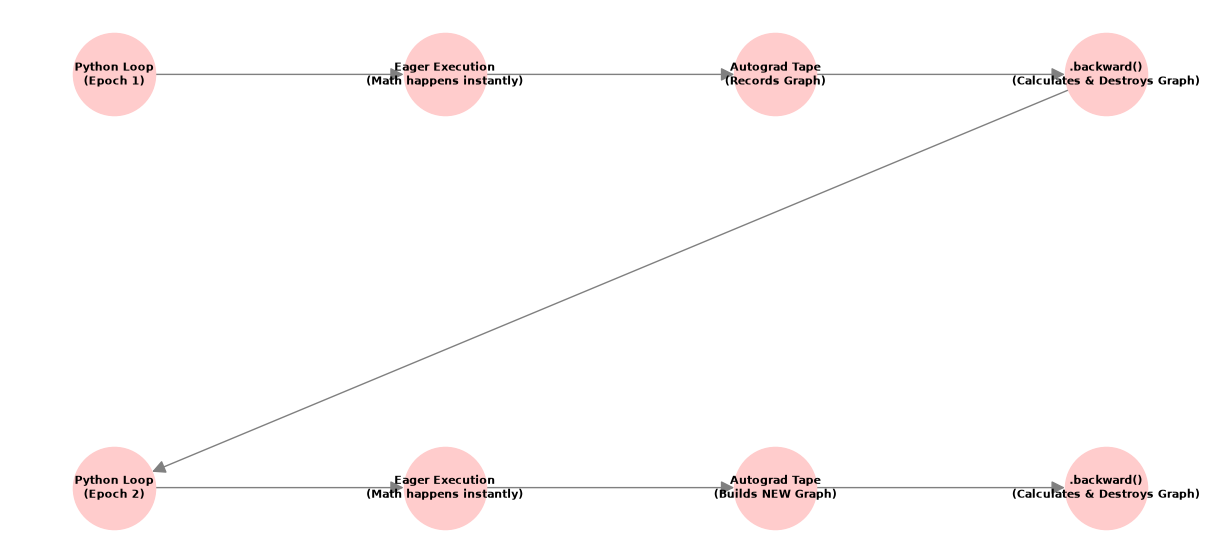


--- JAX: Python is removed. The hardware runs the compiled binary infinitely ---


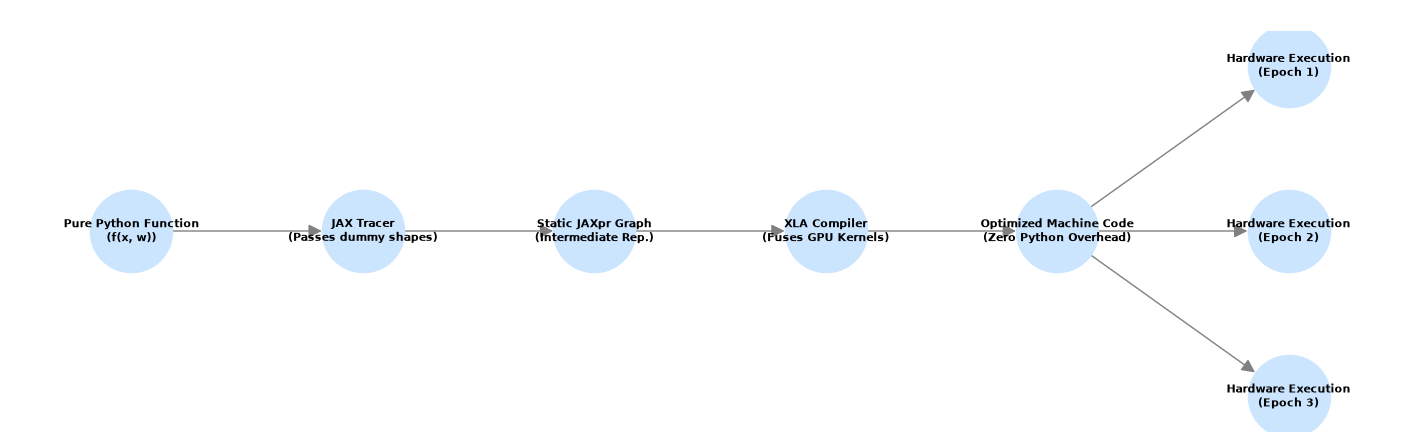

In [8]:
from IPython.display import Image, display

print("--- PyTorch: Python rebuilds the graph every single loop ---")
display(Image(filename='pytorch_dynamic_graph.png'))

print("\n--- JAX: Python is removed. The hardware runs the compiled binary infinitely ---")
display(Image(filename='jax_static_graph.png'))